# Mission Eagle-1 — Pilote automatique pour l'atterrisseur lunaire

**Contexte** : AstroDynamics souhaite automatiser les procédures d'atterrissage de son module Eagle-1.  
L'objectif est d'entraîner un agent par renforcement capable d'atterrir en douceur et avec précision.

---

## Étape 1 — Exploration de l'environnement et modèle de référence

Avant de chercher la performance, on doit comprendre le terrain de jeu et établir un point de départ mesurable.


## 1. Imports et configuration


In [9]:
import os
import warnings

warnings.filterwarnings("ignore")

import gymnasium as gym  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
from stable_baselines3 import DQN  # noqa: E402
from stable_baselines3.common.evaluation import evaluate_policy  # noqa: E402

print("Imports OK")

Imports OK


## 2. Exploration de l'environnement LunarLander-v3

On commence par inspecter les deux espaces fondamentaux : ce que l'agent **observe** et ce qu'il peut **faire**.


In [10]:
env = gym.make("LunarLander-v3")

obs_labels = ["x", "y", "vx", "vy", "theta", "omega", "contact_G", "contact_D"]

print("=== Espace d'observation ===")
print(f"Type      : {type(env.observation_space).__name__}")
print(f"Dimension : {env.observation_space.shape[0]} variables continues\n")
print(f"{'Variable':<12} {'Min':>10} {'Max':>10}")
print("-" * 34)
for label, lo, hi in zip(
    obs_labels, env.observation_space.low, env.observation_space.high
):
    print(f"{label:<12} {lo:>10.3f} {hi:>10.3f}")

print("\n=== Espace d'action ===")
print(f"Type      : {type(env.action_space).__name__}")
print(f"Nb actions: {env.action_space.n}")

=== Espace d'observation ===
Type      : Box
Dimension : 8 variables continues

Variable            Min        Max
----------------------------------
x                -2.500      2.500
y                -2.500      2.500
vx              -10.000     10.000
vy              -10.000     10.000
theta            -6.283      6.283
omega           -10.000     10.000
contact_G        -0.000      1.000
contact_D        -0.000      1.000

=== Espace d'action ===
Type      : Discrete
Nb actions: 4


### 2.1 Signification des variables d'observation

L'espace d'observation contient **8 variables continues** :

| Index | Variable       | Description                       |
| ----- | -------------- | --------------------------------- |
| 0     | x              | Position horizontale du module    |
| 1     | y              | Position verticale (altitude)     |
| 2     | vx             | Vitesse horizontale               |
| 3     | vy             | Vitesse verticale                 |
| 4     | θ (theta)      | Angle d'inclinaison               |
| 5     | ω (omega)      | Vitesse angulaire                 |
| 6     | contact_gauche | Patte gauche en contact (booléen) |
| 7     | contact_droit  | Patte droite en contact (booléen) |

### 2.2 Signification des actions

L'espace d'action est **discret** avec **4 actions** :

| Action | Description                           |
| ------ | ------------------------------------- |
| 0      | Ne rien faire                         |
| 1      | Allumer le propulseur gauche          |
| 2      | Allumer le propulseur principal (bas) |
| 3      | Allumer le propulseur droit           |

### 2.3 Système de récompense

- Atterrissage sur la zone cible : **+100 à +140 points**
- Chaque patte posée : **+10 points**
- Crash : **-100 points**
- Utilisation des propulseurs : pénalité légère (coût carburant)
- **Seuil de réussite : 200 points en moyenne**


### 2.4 Observation d'un épisode aléatoire

On lance un épisode avec des actions aléatoires pour voir le comportement de l'environnement.


In [11]:
obs, info = env.reset()

obs_labels = ["x", "y", "vx", "vy", "theta", "omega", "contact_G", "contact_D"]
print("Observation initiale :")
for label, val in zip(obs_labels, obs):
    print(f"  {label:<12} {val:>8.4f}")

total_reward = 0
n_steps = 0
rewards_random = []

terminated = truncated = False
while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    rewards_random.append(reward)
    n_steps += 1

print(f"\nÉpisode terminé en {n_steps} steps")
print(f"Récompense totale (agent aléatoire) : {total_reward:.2f}")
env.close()

Observation initiale :
  x             -0.0066
  y              1.4138
  vx            -0.6644
  vy             0.1291
  theta          0.0076
  omega          0.1505
  contact_G      0.0000
  contact_D      0.0000

Épisode terminé en 89 steps
Récompense totale (agent aléatoire) : -238.07


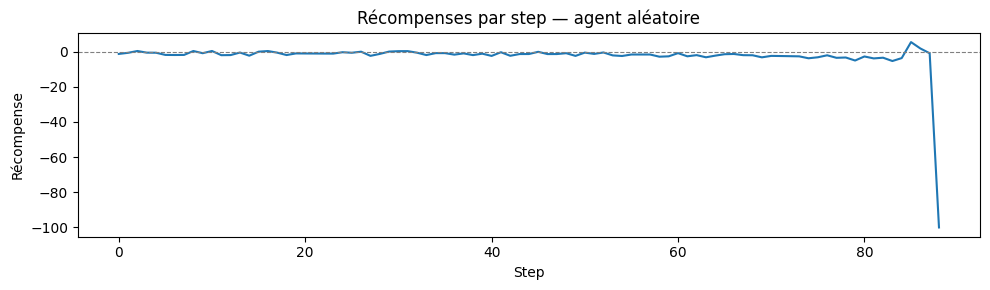

In [12]:
# Distribution des récompenses par step sur l'épisode aléatoire
plt.figure(figsize=(10, 3))
plt.plot(rewards_random)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Récompenses par step — agent aléatoire")
plt.xlabel("Step")
plt.ylabel("Récompense")
plt.tight_layout()
plt.show()

## 3. Choix de l'algorithme

**Espace d'action discret (4 actions)** → on utilise **DQN** (Deep Q-Network).

- PPO serait adapté pour un espace d'action continu (ex. : poussée variable).
- DQN est conçu pour les espaces discrets : il apprend une valeur Q pour chaque paire (état, action) via un réseau de neurones.
- Avantages de DQN ici : stabilité grâce au _replay buffer_ et au _target network_, bon compromis exploration/exploitation via ε-greedy.


## 4. Entraînement du modèle de référence (paramètres par défaut)

On entraîne un premier agent avec les hyperparamètres par défaut de SB3.  
L'objectif n'est pas la performance, mais d'établir une **ligne de base mesurable**.


In [13]:
# Environnement d'entraînement
train_env = gym.make("LunarLander-v3")

# Modèle de référence avec les paramètres par défaut de SB3
baseline_model = DQN(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    seed=42,
)

print("Hyperparamètres par défaut :")
print(f"  learning_rate : {baseline_model.learning_rate}")
print(f"  buffer_size   : {baseline_model.buffer_size}")
print(f"  batch_size    : {baseline_model.batch_size}")
print(f"  gamma         : {baseline_model.gamma}")
print(f"  tau           : {baseline_model.tau}")
print(f"  exploration_initial_eps : {baseline_model.exploration_initial_eps}")
print(f"  exploration_final_eps   : {baseline_model.exploration_final_eps}")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Hyperparamètres par défaut :
  learning_rate : 0.0001
  buffer_size   : 1000000
  batch_size    : 32
  gamma         : 0.99
  tau           : 1.0
  exploration_initial_eps : 1.0
  exploration_final_eps   : 0.05


In [14]:
BASELINE_TIMESTEPS = 100_000

baseline_model.learn(total_timesteps=BASELINE_TIMESTEPS)
train_env.close()

print("Entraînement terminé.")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91       |
|    ep_rew_mean      | -208     |
|    exploration_rate | 0.965    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3787     |
|    time_elapsed     | 0        |
|    total_timesteps  | 364      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.14     |
|    n_updates        | 65       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 88.9     |
|    ep_rew_mean      | -156     |
|    exploration_rate | 0.932    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3260     |
|    time_elapsed     | 0        |
|    total_timesteps  | 711      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.59     |
|    n_updates      

## 5. Évaluation du modèle de référence

On évalue sur **100 épisodes** pour obtenir une mesure statistiquement fiable.


In [15]:
eval_env = gym.make("LunarLander-v3")

N_EVAL_EPISODES = 100
mean_reward, std_reward = evaluate_policy(
    baseline_model,
    eval_env,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
)
eval_env.close()

print(f"Performance du modèle de référence ({BASELINE_TIMESTEPS:,} steps)")
print(f"Récompense moyenne : {mean_reward:.2f}")
print(f"Écart-type         : {std_reward:.2f}")
print(
    f"Intervalle 95%     : [{mean_reward - 2 * std_reward:.2f}, {mean_reward + 2 * std_reward:.2f}]"  # noqa: E501
)
print("\nObjectif à atteindre : 200 points en moyenne")
print(f"Écart à combler      : {200 - mean_reward:.2f} points")

Performance du modèle de référence (100,000 steps)
Récompense moyenne : -35.47
Écart-type         : 144.99
Intervalle 95%     : [-325.46, 254.52]

Objectif à atteindre : 200 points en moyenne
Écart à combler      : 235.47 points


## 6. Sauvegarde du modèle de référence


In [16]:
os.makedirs("models", exist_ok=True)

baseline_model.save("models/dqn_lunarlander_baseline")
print("Modèle de référence sauvegardé dans models/dqn_lunarlander_baseline.zip")

Modèle de référence sauvegardé dans models/dqn_lunarlander_baseline.zip


## 7. Bilan de l'étape 1

| Critère                       | Valeur                        |
| ----------------------------- | ----------------------------- |
| Algorithme choisi             | DQN (espace d'action discret) |
| Steps d'entraînement          | 100 000                       |
| Épisodes d'évaluation         | 100                           |
| Récompense moyenne (baseline) | **-35.47**                    |
| Écart-type                    | **144.99**                    |
| Intervalle 95%                | [-325.46, 254.52]             |
| Objectif étape 2              | > 200 points en moyenne       |

L'écart-type très élevé (144.99) indique que l'agent est très instable : il réussit parfois mais crashe souvent. C'est cohérent avec seulement 100 000 steps d'entraînement et des paramètres par défaut.

**Prochaine étape** : optimisation des hyperparamètres pour dépasser 200 points de récompense moyenne de façon stable.